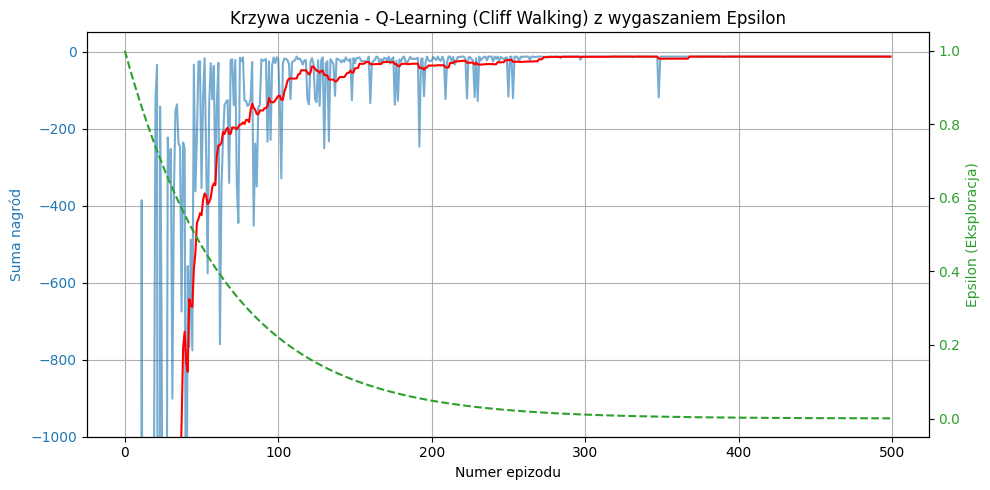

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from q_learning_agent import QLearningAgent

env = gym.make("CliffWalking-v1")

n_states = env.observation_space.n
n_actions = env.action_space.n

# Inicjalizacja z nowymi parametrami wygaszania
agent = QLearningAgent(
    n_states=n_states, 
    n_actions=n_actions, 
    learning_rate=0.1, 
    discount_factor=0.9, 
    epsilon=1.0,          # Zaczynamy od pełnej eksploracji
    epsilon_decay=0.985,  # Dość szybkie wygaszanie (dobrze działa dla 500 epizodów)
    min_epsilon=0.0       # Na koniec pozwalamy mu przestać eksplorować całkowicie
)

n_episodes = 500
rewards_per_episode = []
epsilons_per_episode = [] # Nowa lista do śledzenia epsilona

for episode in range(n_episodes):
    state, info = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        action = agent.get_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        agent.update(state, action, reward, next_state, terminated)
        
        state = next_state
        total_reward += reward
        
    rewards_per_episode.append(total_reward)
    epsilons_per_episode.append(agent.epsilon)
    
    # WYGASZANIE EPSILON NA KONIEC EPIZODU
    agent.decay_epsilon()

env.close()

# Rysowanie wykresów
fig, ax1 = plt.subplots(figsize=(10, 5))

# Wykres nagród (niebieski)
ax1.plot(rewards_per_episode, label='Nagroda na epizod', alpha=0.6, color='tab:blue')
window = 20
moving_avg = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid')
ax1.plot(range(window-1, n_episodes), moving_avg, color='red', label=f'Średnia krocząca ({window} epizodów)')

ax1.set_xlabel('Numer epizodu')
ax1.set_ylabel('Suma nagród', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)
ax1.set_ylim(-1000, 50) # Ogranicza widok osi Y od -1000 do 50

# Wykres epsilon (zielony, na drugiej osi Y)
ax2 = ax1.twinx()  
ax2.plot(epsilons_per_episode, color='tab:green', linestyle='dashed', label='Wartość Epsilon')
ax2.set_ylabel('Epsilon (Eksploracja)', color='tab:green')  
ax2.tick_params(axis='y', labelcolor='tab:green')

plt.title('Krzywa uczenia - Q-Learning (Cliff Walking) z wygaszaniem Epsilon')
fig.tight_layout()
plt.show()